In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def weekday_word(weekday):
    if weekday==0:
        return "Monday"
    elif weekday==1:
        return "Tuesday"
    elif weekday==2:
        return "Wednesday"
    elif weekday==3:
        return "Thursday"
    elif weekday==4:
        return "Friday"
    elif weekday==5:
        return "Saturday"
    else:
        return "Sunday"
    
def is_weekend(weekday):
    return weekday in [5,6]

### Feature forklaring
- User Type: 
    - Customer = 24-hour pass or 3-day pass
    - Subscriber = Annual Member
- Gender:
    - 0 -> Unknown
    - 1 -> Male
    - 2 -> Female

In [3]:
f=pd.read_csv(r"/Users/katrinepedersen/Desktop/Trips_2018.csv")

In [4]:
f.describe()

,Unnamed: 0,tripduration,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,birth_year,gender
count,1.754834e+07,1.754834e+07,1.754584e+07,1.754834e+07,1.754834e+07,1.754584e+07,1.754834e+07,1.754834e+07,1.754834e+07,1.754834e+07,1.754834e+07
mean,8.774169e+06,9.887432e+02,1.589282e+03,4.073737e+01,-7.398260e+01,1.580830e+03,4.073704e+01,-7.398281e+01,2.656141e+04,1.978993e+03,1.148613e+00
std,5.065769e+06,1.889584e+04,1.439432e+03,3.225813e-02,1.912753e-02,1.438502e+03,3.206583e-02,1.919611e-02,6.222916e+03,1.192922e+01,5.438043e-01
min,0.000000e+00,6.100000e+01,7.200000e+01,4.064654e+01,-7.402535e+01,7.200000e+01,4.064654e+01,-7.408364e+01,1.452900e+04,1.885000e+03,0.000000e+00
25%,4.387084e+06,3.580000e+02,3.800000e+02,4.071755e+01,-7.399521e+01,3.800000e+02,4.071755e+01,-7.399595e+01,2.029300e+04,1.969000e+03,1.000000e+00
50%,8.774169e+06,6.050000e+02,5.050000e+02,4.073818e+01,-7.398565e+01,5.050000e+02,4.073756e+01,-7.398602e+01,2.827000e+04,1.981000e+03,1.000000e+00
75%,1.316125e+07,1.060000e+03,3.249000e+03,4.075763e+01,-7.397283e+01,3.249000e+03,4.075725e+01,-7.397344e+01,3.185200e+04,1.989000e+03,1.000000e+00
max,1.754834e+07,1.951005e+07,3.721000e+03,4.550636e+01,-7.356891e+01,3.721000e+03,4.550636e+01,-7.356891e+01,3.583100e+04,2.002000e+03,2.000000e+00


In [5]:
f = f.rename({"Unnamed: 0": "Trip ID"}, axis="columns")
f = f.set_index("Trip ID")

In [6]:
f.head()

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender
Trip ID,,,,,,,,,,,,,
0,970,2018-01-01 13:50:57.4340,2018-01-01 14:07:08.1860,72.0,40.767272,-73.993929,505.0,40.749013,-73.988484,31956,Subscriber,1992,1
1,723,2018-01-01 15:33:30.1820,2018-01-01 15:45:33.3410,72.0,40.767272,-73.993929,3255.0,40.750585,-73.994685,32536,Subscriber,1969,1
2,496,2018-01-01 15:39:18.3370,2018-01-01 15:47:35.1720,72.0,40.767272,-73.993929,525.0,40.755942,-74.002116,16069,Subscriber,1956,1
3,306,2018-01-01 15:40:13.3720,2018-01-01 15:45:20.1910,72.0,40.767272,-73.993929,447.0,40.763707,-73.985162,31781,Subscriber,1974,1
4,306,2018-01-01 18:14:51.5680,2018-01-01 18:19:57.6420,72.0,40.767272,-73.993929,3356.0,40.774667,-73.984706,30319,Subscriber,1992,1


In [7]:
f['starttime'] = pd.to_datetime(f['starttime'], format='%Y-%m-%d %H:%M:%S.%f')
f['stoptime'] = pd.to_datetime(f['stoptime'], format='%Y-%m-%d %H:%M:%S.%f')
f['weekday']= f['starttime'].dt.weekday
f['is_weekend']=[is_weekend(el) for el in f['weekday']]
# sm_dummies=pd.get_dummies(f, columns=['usertype'])
# sm_dummies.head()

In [8]:
f.dtypes

tripduration                        int64
starttime                  datetime64[ns]
stoptime                   datetime64[ns]
start_station_id                  float64
start_station_latitude            float64
start_station_longitude           float64
end_station_id                    float64
end_station_latitude              float64
end_station_longitude             float64
bikeid                              int64
usertype                           object
birth_year                          int64
gender                              int64
weekday                             int32
is_weekend                           bool
dtype: object

In [9]:
# sm_dummies.dtypes

# Looking at coordinates

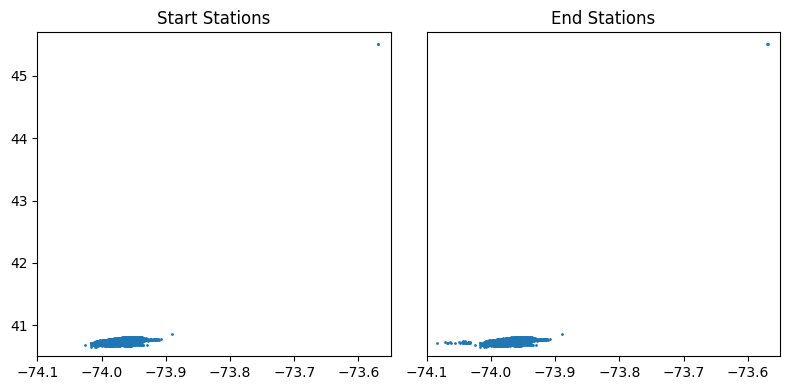

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

xlim, ylim = (-74.1, -73.55), (40.5, 45.7)
dot_size = 1

start_station_df = f.drop_duplicates(subset='start_station_id')[['start_station_id', 'start_station_latitude', 'start_station_longitude']]
start_station_df = start_station_df.set_index("start_station_id")
start_station_df = start_station_df.rename(
    {
        "start_station_latitude": "latitude", 
        "start_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax1.scatter(start_station_df['longitude'],start_station_df['latitude'],s=dot_size)
ax1.set_title("Start Stations")
ax1.set_xlim(*xlim)
ax1.set_ylim(*ylim)

end_station_df = f.drop_duplicates(subset='end_station_id')[['end_station_id', 'end_station_latitude', 'end_station_longitude']]
end_station_df = end_station_df.set_index("end_station_id")
end_station_df = end_station_df.rename(
    {
        "end_station_latitude": "latitude", 
        "end_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax2.scatter(end_station_df['longitude'],end_station_df['latitude'],s=dot_size)
ax2.set_title("End Stations")
ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)
ax2.set_yticks([])

plt.tight_layout()
plt.show()

# Remove outlier

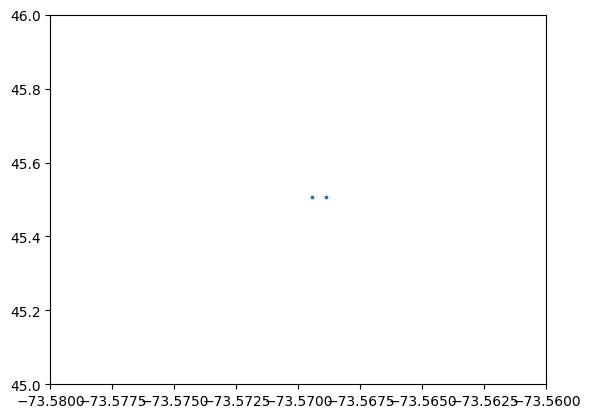

In [11]:
plt.scatter(start_station_df['longitude'], start_station_df['latitude'], s=3)
plt.xlim((-73.58, -73.56))
plt.ylim((45, 46))
plt.show()

In [12]:
start_station_df[start_station_df.longitude > -73.6]

,latitude,longitude
start_station_id,,
3488.0,45.506364,-73.569463
3650.0,45.506264,-73.568906


In [13]:
end_station_df[end_station_df.longitude > -73.6]

,latitude,longitude
end_station_id,,
3488.0,45.506364,-73.569463
3650.0,45.506264,-73.568906


In [14]:
f[
    (f.start_station_id == 3488.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [15]:
f[
    (f.end_station_id == 3488.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,
8772457,1634200,2018-07-18 18:27:51.511,2018-08-06 16:24:32.388,3036.0,40.662908,-73.999722,3488.0,45.506364,-73.569463,24354,Subscriber,1988,1,2,False


In [16]:
f[
    (f.start_station_id == 3650.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [17]:
f[
    (f.end_station_id == 3650.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [18]:
f[
    (f.start_station_id == 3488) | (f.end_station_id == 3488) |
    (f.start_station_id == 3650) | (f.end_station_id == 3650)
].describe()

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,birth_year,gender,weekday
count,8.200000e+01,82,82,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000
mean,2.954804e+04,2018-03-14 21:46:53.854036736,2018-03-15 05:59:22.416878080,3636.585366,45.447203,-73.574180,3642.097561,45.506269,-73.568933,23651.158537,1985.792683,1.012195,1.378049
min,6.200000e+01,2018-01-08 16:03:59.375000,2018-01-08 16:09:41.338000,3036.000000,40.662908,-73.999722,3488.000000,45.506264,-73.569463,17667.000000,1969.000000,0.000000,0.000000
25%,2.235000e+02,2018-01-26 10:59:14.185999872,2018-01-26 12:46:01.522750208,3650.000000,45.506264,-73.568906,3650.000000,45.506264,-73.568906,21928.000000,1986.000000,1.000000,0.000000
50%,9.390000e+02,2018-02-20 14:11:07.361499904,2018-02-20 14:12:41.880000,3650.000000,45.506264,-73.568906,3650.000000,45.506264,-73.568906,24354.000000,1986.000000,1.000000,1.000000
75%,2.653500e+03,2018-05-08 17:10:19.270750208,2018-05-08 17:19:55.421250048,3650.000000,45.506264,-73.568906,3650.000000,45.506264,-73.568906,24354.000000,1986.000000,1.000000,3.000000
max,1.634200e+06,2018-07-18 18:27:51.511000,2018-08-06 16:24:32.388000,3650.000000,45.506364,-73.568906,3650.000000,45.506364,-73.568906,24354.000000,1988.000000,2.000000,4.000000
std,1.827257e+05,NaN,NaN,73.784128,0.534860,0.047574,35.110974,0.000022,0.000121,1256.116408,2.752049,0.248149,1.329998


We have two outliers stations with id 3448 and 3650. We found that they are both placed right next to one another in Montreal, Canada. From the above cells, it is apparent that all but one trips completed with start or end point in Montreal (station 3488 and 3650) are trips in Montreal only.

There is a single trip from Brooklyn (station 3036) to Montreal (station 3488). It's duration is 18.9 days and out of 17 million trips completed, this one is the only one travelling to Montreal. Therefore we classify stations in Montreal as not relevant and outliers.

In [19]:
f = f.drop(
    f[
        (f.start_station_id == 3488) | (f.end_station_id == 3488) |
        (f.start_station_id == 3650) | (f.end_station_id == 3650)
    ].index
)

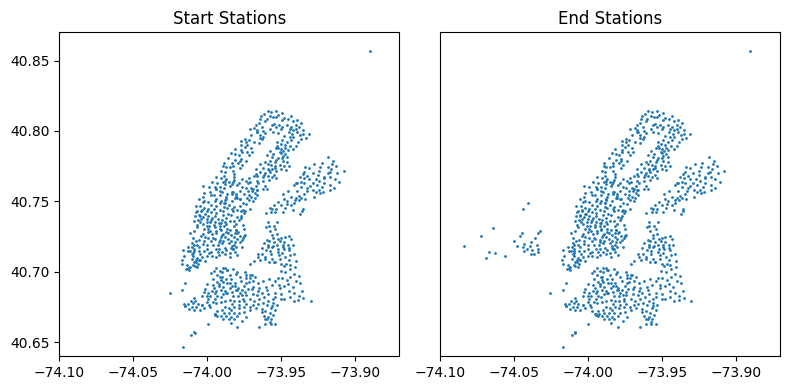

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

xlim, ylim = (-74.1, -73.87), (40.64, 40.87)
dot_size = 1

start_station_df = f.drop_duplicates(subset='start_station_id')[['start_station_id', 'start_station_latitude', 'start_station_longitude']]
start_station_df = start_station_df.set_index("start_station_id")
start_station_df = start_station_df.rename(
    {
        "start_station_latitude": "latitude", 
        "start_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax1.scatter(start_station_df['longitude'],start_station_df['latitude'],s=dot_size)
ax1.set_title("Start Stations")
ax1.set_xlim(*xlim)
ax1.set_ylim(*ylim)

end_station_df = f.drop_duplicates(subset='end_station_id')[['end_station_id', 'end_station_latitude', 'end_station_longitude']]
end_station_df = end_station_df.set_index("end_station_id")
end_station_df = end_station_df.rename(
    {
        "end_station_latitude": "latitude", 
        "end_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax2.scatter(end_station_df['longitude'],end_station_df['latitude'],s=dot_size)
ax2.set_title("End Stations")
ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)
ax2.set_yticks([])

plt.tight_layout()
plt.show()

### Classifying the stations with ID: NaN

We find that a great deal of stations have ID = NaN. So we try and plot them to find their location.

In [21]:
start_ids = np.unique(f.start_station_id)
end_ids = np.unique(f.end_station_id)
print(f"Number of NaN values in start_station_id: {f.start_station_id.isna().sum()}")
print(f"Number of NaN values in end_station_id: {f.end_station_id.isna().sum()}")
start_station_df[start_station_df.index.isna()]

Number of NaN values in start_station_id: 2497
Number of NaN values in end_station_id: 2497


,latitude,longitude
start_station_id,,
NaN,40.857,-73.89


2497 trips have a station ID with NaN-value

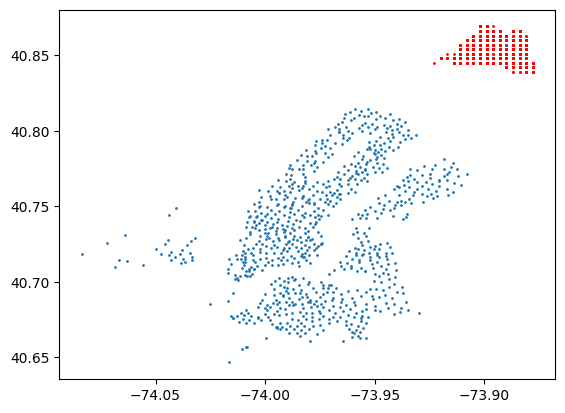

In [22]:
f_nan = f[f.start_station_id.isna()][['start_station_longitude', 'start_station_latitude']]
plt.scatter(f_nan.start_station_longitude, f_nan.start_station_latitude, s=1, c='r', label="NaN-station")
plt.scatter(end_station_df['longitude'], end_station_df['latitude'], s=1)
plt.show()

In [23]:
print("\nCheck: Are the placements different? If all 0, then all placements same")
print(np.unique(f[f.start_station_id.isna()].start_station_longitude) - np.unique(f[f.start_station_id.isna()].end_station_longitude))
print(np.unique(f[f.end_station_id.isna()].start_station_longitude) - np.unique(f[f.end_station_id.isna()].end_station_longitude))
print(np.unique(f[f.start_station_id.isna()].start_station_latitude) - np.unique(f[f.start_station_id.isna()].end_station_latitude))
print(np.unique(f[f.end_station_id.isna()].start_station_latitude) - np.unique(f[f.end_station_id.isna()].end_station_latitude))

print("\nValues for longitude and latitude")
print(np.unique(f[f.start_station_id.isna()].start_station_longitude))
print(np.unique(f[f.start_station_id.isna()].start_station_latitude))

print(f"\nNumber of stations with NaN-value as ID: {len(np.unique(f[f.start_station_id.isna()].start_station_longitude))}")


Check: Are the placements different? If all 0, then all placements same
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Values for longitude and latitude
[-73.923 -73.92  -73.917 -73.914 -73.911 -73.908 -73.905 -73.902 -73.899
 -73.896 -73.893 -73.89  -73.887 -73.884 -73.881 -73.878]
[40.839 40.842 40.845 40.848 40.851 40.854 40.857 40.86  40.863 40.866
 40.869]

Number of stations with NaN-value as ID: 16


Okay, all 16 NaN-ID-stations are located in a single 'cluster' or grouping.
Looking at the placement in a map, the red grouping lies in the Bronx area North of New York. Also as a result of our plotting the single blue dot is the result of dropping duplicates on the ID's. This means that it, in previous plots, represented all the red dots, we now found.

We check whether or not we have data on any trips leaving this grouping. 

In [24]:
f[(f.start_station_id.isna()) & (f.end_station_id.notna())]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [25]:
f[(f.start_station_id.notna()) & (f.end_station_id.isna())]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


Okay, no trips from a NaN-ID-station leaves the grouping in the Bronx area. Hence, they have no implication on clusters in the central New York area. Since that is the case they wont be important for rebalancing the bike locations, so we classicy them as outliers

In [26]:
f = f.dropna()

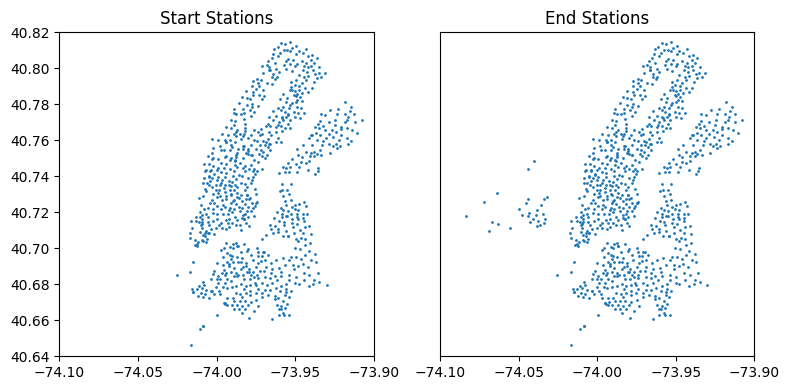

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

xlim, ylim = (-74.1, -73.9), (40.64, 40.82)
dot_size = 1

start_station_df = f.drop_duplicates(subset='start_station_id')[['start_station_id', 'start_station_latitude', 'start_station_longitude']]
start_station_df = start_station_df.set_index("start_station_id")
start_station_df = start_station_df.rename(
    {
        "start_station_latitude": "latitude", 
        "start_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax1.scatter(start_station_df['longitude'],start_station_df['latitude'],s=dot_size)
ax1.set_title("Start Stations")
ax1.set_xlim(*xlim)
ax1.set_ylim(*ylim)

end_station_df = f.drop_duplicates(subset='end_station_id')[['end_station_id', 'end_station_latitude', 'end_station_longitude']]
end_station_df = end_station_df.set_index("end_station_id")
end_station_df = end_station_df.rename(
    {
        "end_station_latitude": "latitude", 
        "end_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax2.scatter(end_station_df['longitude'],end_station_df['latitude'],s=dot_size)
ax2.set_title("End Stations")
ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)
ax2.set_yticks([])

plt.tight_layout()
plt.show()

## K-means

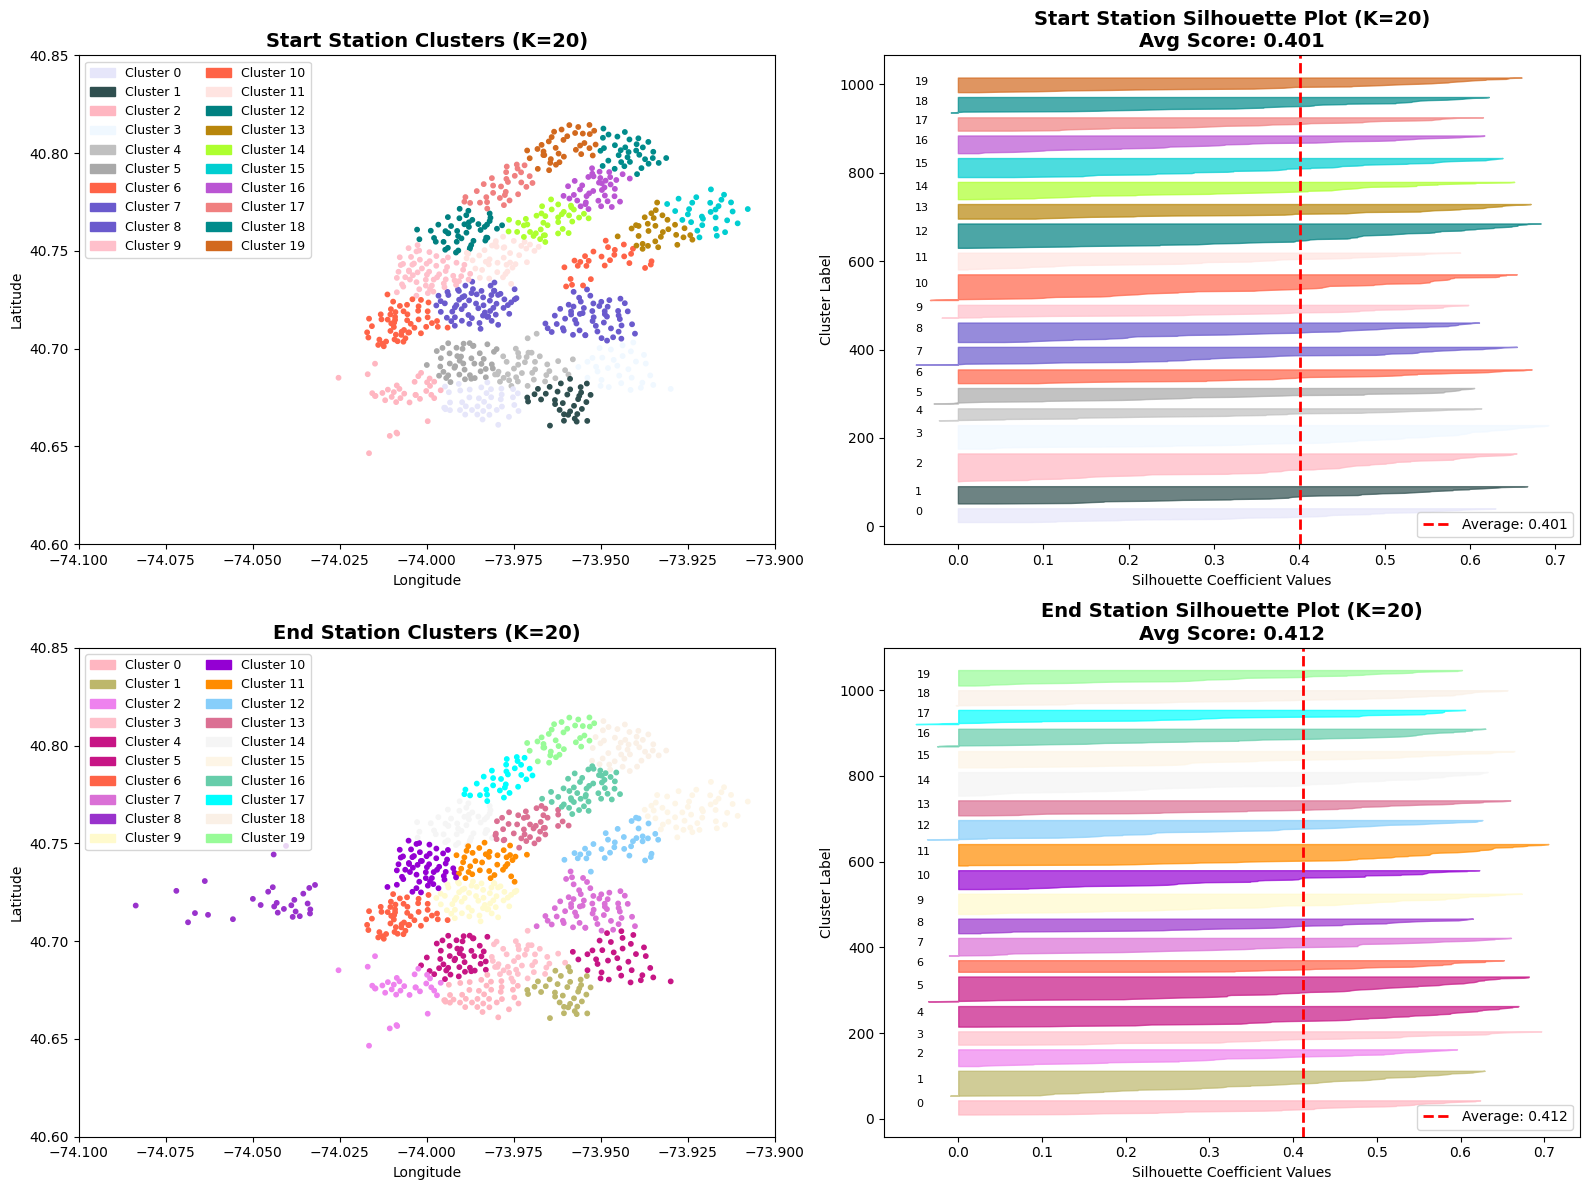

Start Station Average Silhouette Score: 0.401
End Station Average Silhouette Score: 0.412


In [28]:
from sklearn.cluster import KMeans
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
import random

K=20

# Fit K-means for start stations
k_start=KMeans(K, random_state=42, n_init=30)
k_end=KMeans(K, random_state=42, n_init=30)

k_start.fit(start_station_df)
k_end.fit(end_station_df)
centroids_start = k_start.cluster_centers_
centroids_end = k_end.cluster_centers_

# Fixing labelling start
order = np.argsort(centroids_start[:, 0])
mapping = {old: new for new, old in enumerate(order)}
fix_labels_start = np.array([mapping[label] for label in k_start.labels_])

# Fixing labelling end
order = np.argsort(centroids_end[:, 0])
mapping = {old: new for new, old in enumerate(order)}
fix_labels_end = np.array([mapping[label] for label in k_end.labels_])

dt_clusters_start=start_station_df.copy()
dt_clusters_start['cluster']= fix_labels_start

dt_clusters_end=end_station_df.copy()
dt_clusters_end['cluster']=fix_labels_end

# Generate colors
num_colors=K
colors=list(mcolors.CSS4_COLORS.keys())
cluster_colors_start = random.choices(colors,k=K)
cluster_colors_end = random.choices(colors,k=K)

# Prepare data for start stations
x_points_start=dt_clusters_start["longitude"]
y_points_start=dt_clusters_start["latitude"]
labels_start = dt_clusters_start["cluster"]
x_start=[]
y_start=[]
c_start=[]
for label, x, y in zip(labels_start, x_points_start, y_points_start):
    if label == -1:
        continue
    x_start.append(x)
    y_start.append(y)
    c_start.append(cluster_colors_start[label])

# Prepare data for end stations
x_points_end=dt_clusters_end["longitude"]
y_points_end=dt_clusters_end["latitude"]
labels_end = dt_clusters_end["cluster"]
x_end=[]
y_end=[]
c_end=[]
for label, x, y in zip(labels_end, x_points_end, y_points_end):
    if label==-1:
        continue
    x_end.append(x)
    y_end.append(y)
    c_end.append(cluster_colors_end[label])

# Calculate silhouette scores
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

silhouette_avg_start = silhouette_score(start_station_df, k_start.labels_)
sample_silhouette_values_start = silhouette_samples(start_station_df, k_start.labels_)

silhouette_avg_end = silhouette_score(end_station_df, k_end.labels_)
sample_silhouette_values_end = silhouette_samples(end_station_df, k_end.labels_)

# Create combined plot with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Start Station Clusters
ax1 = axes[0, 0]
ax1.scatter(x_start, y_start, s=10, c=c_start)
ax1.set_xlim(-74.1, -73.9)
ax1.set_ylim(40.6, 40.85)
ax1.set_title(f'Start Station Clusters (K={K})', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
legend_patches_start = [Patch(color=cluster_colors_start[i], label=f"Cluster {i}") for i in range(K)]
ax1.legend(handles=legend_patches_start, loc='upper left', fontsize=9, ncol=2)

# Plot 2: Start Station Silhouette Plot
ax2 = axes[0, 1]
y_lower = 10
for i in range(K):
    ith_cluster_silhouette_values = sample_silhouette_values_start[k_start.labels_ == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cluster_colors_start[i]
    ax2.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax2.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=8)
    y_lower = y_upper + 10
ax2.set_title(f"Start Station Silhouette Plot (K={K})\nAvg Score: {silhouette_avg_start:.3f}", 
              fontsize=14, fontweight='bold')
ax2.set_xlabel("Silhouette Coefficient Values")
ax2.set_ylabel("Cluster Label")
ax2.axvline(x=silhouette_avg_start, color="red", linestyle="--", linewidth=2, 
            label=f"Average: {silhouette_avg_start:.3f}")
ax2.legend()

# Plot 3: End Station Clusters
ax3 = axes[1, 0]
ax3.scatter(x_end, y_end, s=10, c=c_end)
ax3.set_xlim(-74.1, -73.9)
ax3.set_ylim(40.6, 40.85)
ax3.set_title(f'End Station Clusters (K={K})', fontsize=14, fontweight='bold')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
legend_patches_end = [Patch(color=cluster_colors_end[i], label=f"Cluster {i}") for i in range(K)]
ax3.legend(handles=legend_patches_end, loc='upper left', fontsize=9, ncol=2)

# Plot 4: End Station Silhouette Plot
ax4 = axes[1, 1]
y_lower = 10
for i in range(K):
    ith_cluster_silhouette_values = sample_silhouette_values_end[k_end.labels_ == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cluster_colors_end[i]
    ax4.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax4.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=8)
    y_lower = y_upper + 10
ax4.set_title(f"End Station Silhouette Plot (K={K})\nAvg Score: {silhouette_avg_end:.3f}", 
              fontsize=14, fontweight='bold')
ax4.set_xlabel("Silhouette Coefficient Values")
ax4.set_ylabel("Cluster Label")
ax4.axvline(x=silhouette_avg_end, color="red", linestyle="--", linewidth=2, 
            label=f"Average: {silhouette_avg_end:.3f}")
ax4.legend()

plt.tight_layout()
plt.show()

print(f"Start Station Average Silhouette Score: {silhouette_avg_start:.3f}")
print(f"End Station Average Silhouette Score: {silhouette_avg_end:.3f}")

# Load a fixed labelling from file

In [29]:
# np.savetxt('fix_labels_end.txt', fix_labels_end) # for updating the fixed cluster labelling used


fixed_cluster_labels = np.loadtxt('/Users/katrinepedersen/Desktop/Business_analytics/fix_labels_start.txt')
dt_clusters_all = dt_clusters_start.copy() # All stations are represented in end_station_id column
dt_clusters_all['cluster'] = fixed_cluster_labels

# Connect clusters with the 17 mio data frame

In [30]:
df_merged_start = f.merge(
    dt_clusters_all['cluster'], 
    left_on='start_station_id', 
    right_index=True, 
    how='left'
)
# df_merged_start = df_merged_start.drop(columns=['Unnamed: 0'])

df_merged_end = f.merge(
    dt_clusters_all['cluster'], 
    left_on='end_station_id', 
    right_index=True, 
    how='left'
)

In [31]:
np.unique(dt_clusters_all[dt_clusters_all.cluster == 8].index)

array([ 150.,  151.,  229.,  236.,  237.,  251.,  265.,  266.,  291.,
        293.,  295.,  297.,  301.,  302.,  307.,  311.,  312.,  317.,
        326.,  331.,  332.,  335.,  339.,  340.,  341.,  342.,  349.,
        350.,  356.,  361.,  393.,  394.,  400.,  401.,  403.,  410.,
        411.,  412.,  428.,  432.,  433.,  438.,  439.,  445.,  473.,
        483.,  502.,  504.,  531., 2003., 3245., 3250., 3260., 3263.,
       3427., 3435., 3468., 3485., 3632., 3656., 3683., 3695., 3711.,
       3718.])

# Investigating a cluster

In [32]:
cluster_4_departures = df_merged_start[df_merged_start["cluster"] == 4].copy()
cluster_4_arrivals = df_merged_end[df_merged_end['cluster'] == 4].copy()
cluster_4_departures.size, cluster_4_arrivals.size

(7780032, 7589120)

In [33]:
cluster_4_departures.head()

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend,cluster
Trip ID,,,,,,,,,,,,,,,,
2866,904,2018-01-01 08:20:14.048,2018-01-01 08:35:18.290,83.0,40.683826,-73.976323,3300.0,40.665147,-73.976376,31085,Subscriber,1973,1,0,False,4.0
2867,162,2018-01-01 14:56:10.536,2018-01-01 14:58:53.280,83.0,40.683826,-73.976323,3414.0,40.680945,-73.975673,33431,Subscriber,1975,2,0,False,4.0
2868,543,2018-01-01 16:29:05.882,2018-01-01 16:38:09.580,83.0,40.683826,-73.976323,3581.0,40.674012,-73.967146,33352,Subscriber,1986,1,0,False,4.0
2869,330,2018-01-01 16:33:07.794,2018-01-01 16:38:38.149,83.0,40.683826,-73.976323,3413.0,40.682755,-73.982586,17048,Subscriber,1949,1,0,False,4.0
2870,476,2018-01-01 17:15:33.336,2018-01-01 17:23:29.574,83.0,40.683826,-73.976323,3242.0,40.691029,-73.991834,29345,Subscriber,1979,1,0,False,4.0


# Data visualization for a cluster

# Further investigation of what variables to keep for our prediction model

We discussed: leaving out starttime, stoptime, and longitude and latitude for both end station and startstation. The spatial because we now just care which cluster we are in, therefore also leave out the stations ID. Starttime is relevant stop time not su much because we try to predict demand. ANd the trip duration will be kept, also weekend, birth year, most common usertype, and most common gender. Bike ID have also been left out as it seems irrelevant to know which bike goes where at this point. 

In [34]:


# Make sure starttime is a datetime
cluster_4_arrivals['stoptime'] = pd.to_datetime(cluster_4_arrivals['stoptime'])

# Extract date and hour
cluster_4_arrivals['date'] = cluster_4_arrivals['stoptime'].dt.date
cluster_4_arrivals['hour'] = cluster_4_arrivals['stoptime'].dt.hour

# Group by date and hour, count trips
trips_per_hour_arrivals= cluster_4_arrivals.groupby(['date', 'hour'])
trips_per_hour_arrivals.head()

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend,cluster,date,hour
Trip ID,,,,,,,,,,,,,,,,,,
2051,1313,2018-01-24 09:12:55.376,2018-01-24 09:34:48.533,79.0,40.719116,-74.006667,242.0,40.697787,-73.973736,32585,Subscriber,1983,1,2,False,4.0,2018-01-24,9
2707,1267,2018-01-22 17:29:54.723,2018-01-22 17:51:02.091,82.0,40.711174,-74.000165,3455.0,40.686808,-73.980362,31410,Subscriber,1969,1,0,False,4.0,2018-01-22,17
2867,162,2018-01-01 14:56:10.536,2018-01-01 14:58:53.280,83.0,40.683826,-73.976323,3414.0,40.680945,-73.975673,33431,Subscriber,1975,2,0,False,4.0,2018-01-01,14
2871,566,2018-01-01 18:23:45.044,2018-01-01 18:33:11.374,83.0,40.683826,-73.976323,262.0,40.691782,-73.973730,32309,Subscriber,1977,1,0,False,4.0,2018-01-01,18
2873,454,2018-01-01 21:44:49.900,2018-01-01 21:52:24.423,83.0,40.683826,-73.976323,270.0,40.693083,-73.971789,32335,Subscriber,1980,1,0,False,4.0,2018-01-01,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17548232,249,2018-12-31 22:35:42.645,2018-12-31 22:39:52.255,3410.0,40.686444,-73.987591,467.0,40.683125,-73.978951,18157,Customer,1969,0,0,False,4.0,2018-12-31,22
17548269,317,2018-12-31 23:03:31.570,2018-12-31 23:08:49.156,274.0,40.686919,-73.976682,275.0,40.686501,-73.965633,19468,Subscriber,2002,1,0,False,4.0,2018-12-31,23
17548293,303,2018-12-31 23:18:56.184,2018-12-31 23:23:59.389,390.0,40.692216,-73.984284,270.0,40.693083,-73.971789,14736,Subscriber,1987,1,0,False,4.0,2018-12-31,23


In [35]:

grouped_arrivals = (
    cluster_4_arrivals.groupby(['date', 'hour'])
      .agg(
          trip_count=('tripduration', 'count'),
          is_weekend=('is_weekend', 'first'),
          most_common_user_type=('usertype', lambda x: x.value_counts().index[0]),
          most_common_gender=('gender', lambda x: x.value_counts().index[0]),
          duration_mean=('tripduration', 'mean'),
          birth_mean=('birth_year', 'mean')
      )
      .reset_index()
)


In [36]:
grouped_arrivals.head()

,date,hour,trip_count,is_weekend,most_common_user_type,most_common_gender,duration_mean,birth_mean
0,2018-01-01,0,4,False,Subscriber,1,414.250000,1982.750000
1,2018-01-01,1,5,False,Subscriber,1,1337.000000,1981.200000
2,2018-01-01,2,6,False,Subscriber,1,713.666667,1976.666667
3,2018-01-01,3,5,False,Subscriber,1,1105.000000,1986.400000
4,2018-01-01,4,5,False,Subscriber,1,374.200000,1977.200000


In [37]:
grouped_arrivals['datetime'] = pd.to_datetime(grouped_arrivals['date'].astype(str)) + pd.to_timedelta(grouped_arrivals['hour'], unit='h')
grouped_arrivals.set_index('datetime', inplace=True)
#grouped_arrivals.drop(columns=['date'], inplace=True)
#grouped_arrivals.drop(columns=['hour'], inplace=True)
#grouped_arrivals = grouped_arrivals[~(grouped_arrivals.index.date == pd.to_datetime('2019-01-04').date())]
grouped_arrivals

,date,hour,trip_count,is_weekend,most_common_user_type,most_common_gender,duration_mean,birth_mean
datetime,,,,,,,,
2018-01-01 00:00:00,2018-01-01,0,4,False,Subscriber,1,4.142500e+02,1982.750000
2018-01-01 01:00:00,2018-01-01,1,5,False,Subscriber,1,1.337000e+03,1981.200000
2018-01-01 02:00:00,2018-01-01,2,6,False,Subscriber,1,7.136667e+02,1976.666667
2018-01-01 03:00:00,2018-01-01,3,5,False,Subscriber,1,1.105000e+03,1986.400000
2018-01-01 04:00:00,2018-01-01,4,5,False,Subscriber,1,3.742000e+02,1977.200000
...,...,...,...,...,...,...,...,...
2018-12-31 20:00:00,2018-12-31,20,4,False,Subscriber,1,5.062500e+02,1990.000000
2018-12-31 21:00:00,2018-12-31,21,4,False,Subscriber,1,1.846500e+03,1972.000000
2018-12-31 22:00:00,2018-12-31,22,3,False,Subscriber,1,3.493333e+02,1979.666667


In [38]:
all_dates = np.unique(grouped_arrivals.index.date)


In [39]:
all_hours = pd.Index(range(24), name='hour')

full_index = pd.MultiIndex.from_product(
    [all_dates, all_hours],
    names = ['date', 'hour']
)

grouped_arrivals = (
    grouped_arrivals
        .set_index(['date', 'hour'])
        .reindex(full_index, fill_value=0)
        .reset_index()
)
grouped_arrivals.tail(24)

,date,hour,trip_count,is_weekend,most_common_user_type,most_common_gender,duration_mean,birth_mean
8760,2019-01-04,0,0,0,0,0,0.0,0.0
8761,2019-01-04,1,0,0,0,0,0.0,0.0
8762,2019-01-04,2,0,0,0,0,0.0,0.0
8763,2019-01-04,3,0,0,0,0,0.0,0.0
8764,2019-01-04,4,0,0,0,0,0.0,0.0
8765,2019-01-04,5,0,0,0,0,0.0,0.0
8766,2019-01-04,6,0,0,0,0,0.0,0.0
8767,2019-01-04,7,0,0,0,0,0.0,0.0
8768,2019-01-04,8,0,0,0,0,0.0,0.0
8769,2019-01-04,9,0,0,0,0,0.0,0.0


In [40]:

grouped_arrivals['datetime'] = pd.to_datetime(grouped_arrivals['date'].astype(str)) + pd.to_timedelta(grouped_arrivals['hour'], unit='h')
grouped_arrivals.set_index('datetime', inplace=True)
grouped_arrivals.drop(columns=['date'], inplace=True)
grouped_arrivals.drop(columns=['hour'], inplace=True)


In [41]:
grouped_arrivals.head(10)

,trip_count,is_weekend,most_common_user_type,most_common_gender,duration_mean,birth_mean
datetime,,,,,,
2018-01-01 00:00:00,4,False,Subscriber,1,414.250000,1982.750000
2018-01-01 01:00:00,5,False,Subscriber,1,1337.000000,1981.200000
2018-01-01 02:00:00,6,False,Subscriber,1,713.666667,1976.666667
2018-01-01 03:00:00,5,False,Subscriber,1,1105.000000,1986.400000
2018-01-01 04:00:00,5,False,Subscriber,1,374.200000,1977.200000
2018-01-01 05:00:00,0,0,0,0,0.000000,0.000000
2018-01-01 06:00:00,2,False,Subscriber,1,690.500000,1970.500000
2018-01-01 07:00:00,1,False,Subscriber,1,399.000000,1984.000000
2018-01-01 08:00:00,2,False,Subscriber,1,751.500000,1982.000000


In [42]:

# Make sure starttime is a datetime
cluster_4_departures['starttime'] = pd.to_datetime(cluster_4_departures['starttime'])

# Extract date and hour
cluster_4_departures['date'] = cluster_4_departures['starttime'].dt.date
cluster_4_departures['hour'] = cluster_4_departures['starttime'].dt.hour

# Group by date and hour, count trips
trips_per_hour_decluster_4_departures= cluster_4_departures.groupby(['date', 'hour'])
trips_per_hour_decluster_4_departures.head()

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend,cluster,date,hour
Trip ID,,,,,,,,,,,,,,,,,,
2866,904,2018-01-01 08:20:14.048,2018-01-01 08:35:18.290,83.0,40.683826,-73.976323,3300.0,40.665147,-73.976376,31085,Subscriber,1973,1,0,False,4.0,2018-01-01,8
2867,162,2018-01-01 14:56:10.536,2018-01-01 14:58:53.280,83.0,40.683826,-73.976323,3414.0,40.680945,-73.975673,33431,Subscriber,1975,2,0,False,4.0,2018-01-01,14
2868,543,2018-01-01 16:29:05.882,2018-01-01 16:38:09.580,83.0,40.683826,-73.976323,3581.0,40.674012,-73.967146,33352,Subscriber,1986,1,0,False,4.0,2018-01-01,16
2869,330,2018-01-01 16:33:07.794,2018-01-01 16:38:38.149,83.0,40.683826,-73.976323,3413.0,40.682755,-73.982586,17048,Subscriber,1949,1,0,False,4.0,2018-01-01,16
2870,476,2018-01-01 17:15:33.336,2018-01-01 17:23:29.574,83.0,40.683826,-73.976323,3242.0,40.691029,-73.991834,29345,Subscriber,1979,1,0,False,4.0,2018-01-01,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17548269,317,2018-12-31 23:03:31.570,2018-12-31 23:08:49.156,274.0,40.686919,-73.976682,275.0,40.686501,-73.965633,19468,Subscriber,2002,1,0,False,4.0,2018-12-31,23
17548283,657,2018-12-31 23:10:25.447,2018-12-31 23:21:23.344,366.0,40.693261,-73.968896,3064.0,40.696820,-73.937569,35768,Subscriber,1994,1,0,False,4.0,2018-12-31,23
17548287,1005,2018-12-31 23:15:26.970,2018-12-31 23:32:12.227,3637.0,40.683239,-73.965996,3092.0,40.719009,-73.958525,30255,Subscriber,1977,1,0,False,4.0,2018-12-31,23


In [43]:
grouped_departures = (
    cluster_4_departures.groupby(['date', 'hour'])
      .agg(
          trip_count=('tripduration', 'count'),
          is_weekend=('is_weekend', 'first'),
          most_common_user_type=('usertype', lambda x: x.value_counts().index[0]),
          most_common_gender=('gender', lambda x: x.value_counts().index[0]),
          duration_mean=('tripduration', 'mean'),
          birth_mean=('birth_year', 'mean')
      )
      .reset_index()
)

In [44]:
grouped_departures = (
    grouped_departures
        .set_index(['date', 'hour'])
        .reindex(full_index, fill_value=0)
        .reset_index()
)

grouped_departures['datetime'] = pd.to_datetime(grouped_departures['date'].astype(str)) + pd.to_timedelta(grouped_departures['hour'], unit='h')
grouped_departures.set_index('datetime', inplace=True)
grouped_departures.drop(columns=['date'], inplace=True)
grouped_departures.drop(columns=['hour'], inplace=True)

In [45]:
grouped_departures

,trip_count,is_weekend,most_common_user_type,most_common_gender,duration_mean,birth_mean
datetime,,,,,,
2018-01-01 00:00:00,2,False,Subscriber,1,216.0,1976.000000
2018-01-01 01:00:00,3,False,Subscriber,1,955.0,1981.333333
2018-01-01 02:00:00,4,False,Subscriber,1,448.5,1981.500000
2018-01-01 03:00:00,1,False,Subscriber,1,303.0,1989.000000
2018-01-01 04:00:00,1,False,Subscriber,1,227.0,1969.000000
...,...,...,...,...,...,...
2019-01-04 19:00:00,0,0,0,0,0.0,0.000000
2019-01-04 20:00:00,0,0,0,0,0.0,0.000000
2019-01-04 21:00:00,0,0,0,0,0.0,0.000000


# Starting to build model

## Naive model - predict same val for trip_count as 24 h before departures and arrivals 

In [46]:
def weekday_hour_average(series):
    """
    Predicts hourly trip count based on the historical average for
    each (weekday, hour) combination.
    
    Input:
        series: Pandas Series with DatetimeIndex (hourly data)
    
    Output:
        Pandas Series of predictions aligned with the input index.
    """
    df = series.to_frame("trip_count").copy()

    # Extract weekday (0=Monday,...6=Sunday) and hour of day
    df["weekday"] = df.index.weekday
    df["hour"] = df.index.hour

    # Compute the historical average for each weekday + hour combination
    avg_table = (
        df.groupby(["weekday", "hour"])["trip_count"]
          .mean()
          .round()
          .rename("avg_pred")
    )

    return avg_table

def predict_weekday_hour(series, avg_table):
    """
    Predicts for any datetime-indexed series using a fitted avg_table.
    """
    df = series.to_frame("x").copy()
    df["weekday"] = df.index.weekday
    df["hour"] = df.index.hour

    # map (weekday, hour) → prediction
    preds = [
        avg_table.loc[(w, h)]
        for w, h in zip(df["weekday"], df["hour"])
    ]
    
    return pd.Series(preds, index=df.index)


def plotprediction(series, pred_series, labels=["original", "predicted"], x_axis=None, plot_intervals=False, scale=1.96, plot_anomalies=False, title="prediction"):

    plt.figure(figsize=(15,5))
    plt.title(title)
    if x_axis is None:
            x_axis=series.index
    
    plt.plot(x_axis, pred_series, "r", label=labels[1])
    plt.plot(x_axis, series, 'b', label=labels[0])
    

    # Plot confidence intervals for smoothed values

    plt.legend(loc="upper left")
    plt.grid(True)
    plt.show()


## Departures

In [47]:
# Make sure the index is a DatetimeIndex
grouped_departures.index = pd.to_datetime(grouped_departures.index)



test_start = pd.Timestamp("2018-11-01")
test_stop = pd.Timestamp("2019-01-01")

train_mask = grouped_departures.index < test_start
test_mask  =  (test_stop >grouped_departures.index) & (grouped_departures.index  >= test_start)

train_departures = grouped_departures[train_mask].iloc[:, 0]
test_departures  = grouped_departures[test_mask].iloc[:, 0]


In [48]:
model_table_departures= weekday_hour_average(train_departures)
model_table_departures[:25]

weekday  hour
0        0         8.0
         1         5.0
         2         3.0
         3         1.0
         4         3.0
         5        11.0
         6        39.0
         7        86.0
         8       149.0
         9        99.0
         10       48.0
         11       50.0
         12       54.0
         13       58.0
         14       56.0
         15       62.0
         16       72.0
         17      106.0
         18      139.0
         19      108.0
         20       69.0
         21       47.0
         22       35.0
         23       20.0
1        0         9.0
Name: avg_pred, dtype: float64

In [49]:

pred_test_departures = predict_weekday_hour(test_departures, model_table_departures)
pred_test_departures

datetime
2018-11-01 00:00:00     12.0
2018-11-01 01:00:00      5.0
2018-11-01 02:00:00      3.0
2018-11-01 03:00:00      2.0
2018-11-01 04:00:00      4.0
                       ...  
2018-12-31 19:00:00    108.0
2018-12-31 20:00:00     69.0
2018-12-31 21:00:00     47.0
2018-12-31 22:00:00     35.0
2018-12-31 23:00:00     20.0
Length: 1464, dtype: float64

In [50]:
test_departures.tail(24)

datetime
2018-12-31 00:00:00     3
2018-12-31 01:00:00     8
2018-12-31 02:00:00     3
2018-12-31 03:00:00     3
2018-12-31 04:00:00     4
2018-12-31 05:00:00     3
2018-12-31 06:00:00    11
2018-12-31 07:00:00    40
2018-12-31 08:00:00    53
2018-12-31 09:00:00    53
2018-12-31 10:00:00    52
2018-12-31 11:00:00    65
2018-12-31 12:00:00    62
2018-12-31 13:00:00    54
2018-12-31 14:00:00    35
2018-12-31 15:00:00    30
2018-12-31 16:00:00    22
2018-12-31 17:00:00    12
2018-12-31 18:00:00    10
2018-12-31 19:00:00     4
2018-12-31 20:00:00     6
2018-12-31 21:00:00     0
2018-12-31 22:00:00     1
2018-12-31 23:00:00     6
Name: trip_count, dtype: int64

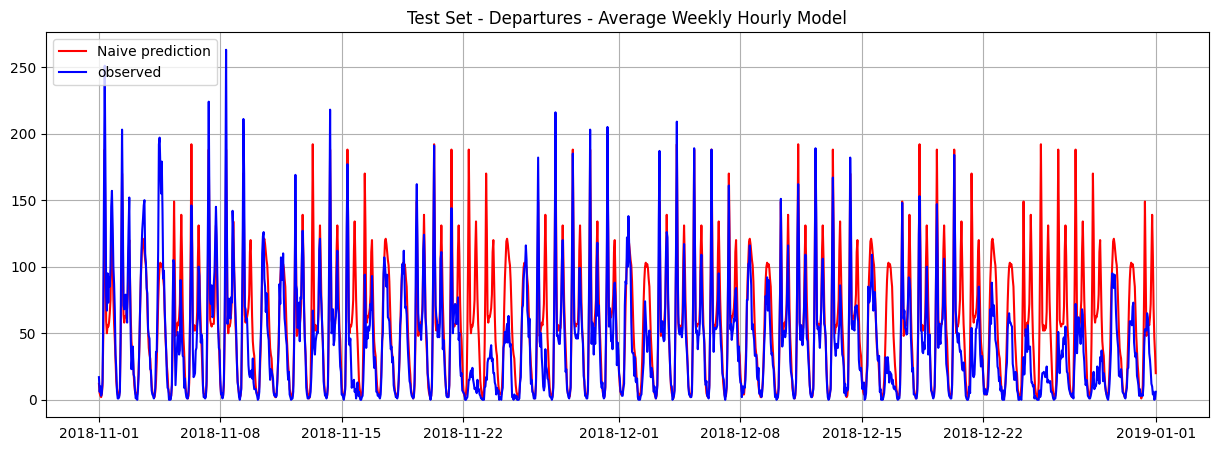

In [51]:
plotprediction(
    test_departures,
    pred_test_departures,
    labels=["observed", "Naive prediction"],
    title="Test Set - Departures - Average Weekly Hourly Model",
)

### Eval. of Naive model

In [52]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def print_stats(y_test, y_preds, title="You forgot the title!"):
    print(title+": ")
    print("\tr^2=%f"%r2_score(y_test,y_preds))
    print("\tMSE=%f"%mean_squared_error(y_test,y_preds))
    print("\tMAE=%f"%mean_absolute_error(y_test,y_preds))
    print("\tMAPE=%f"%mean_absolute_percentage_error(y_test,y_preds))

In [53]:
print_stats(test_departures, pred_test_departures, "Naive method departures")

Naive method departures: 
	r^2=0.469399
	MSE=934.183060
	MAE=19.075137
	MAPE=inf


## Arrivals 

In [54]:
# Make sure the index is a DatetimeIndex
grouped_arrivals.index = pd.to_datetime(grouped_arrivals.index)


train_arrivals = grouped_arrivals[train_mask].iloc[:, 0]
test_arrivals  = grouped_arrivals[test_mask].iloc[:, 0]

In [55]:
model_table_arrivals= weekday_hour_average(train_arrivals)
model_table_arrivals[:25]

weekday  hour
0        0        10.0
         1         6.0
         2         3.0
         3         2.0
         4         3.0
         5         9.0
         6        25.0
         7        51.0
         8        94.0
         9        84.0
         10       44.0
         11       42.0
         12       50.0
         13       56.0
         14       56.0
         15       60.0
         16       76.0
         17      115.0
         18      170.0
         19      141.0
         20       96.0
         21       61.0
         22       44.0
         23       27.0
1        0        13.0
Name: avg_pred, dtype: float64

In [56]:
pred_test_arrivals = predict_weekday_hour(test_arrivals, model_table_arrivals)
pred_test_arrivals

datetime
2018-11-01 00:00:00     17.0
2018-11-01 01:00:00      6.0
2018-11-01 02:00:00      3.0
2018-11-01 03:00:00      2.0
2018-11-01 04:00:00      3.0
                       ...  
2018-12-31 19:00:00    141.0
2018-12-31 20:00:00     96.0
2018-12-31 21:00:00     61.0
2018-12-31 22:00:00     44.0
2018-12-31 23:00:00     27.0
Length: 1464, dtype: float64

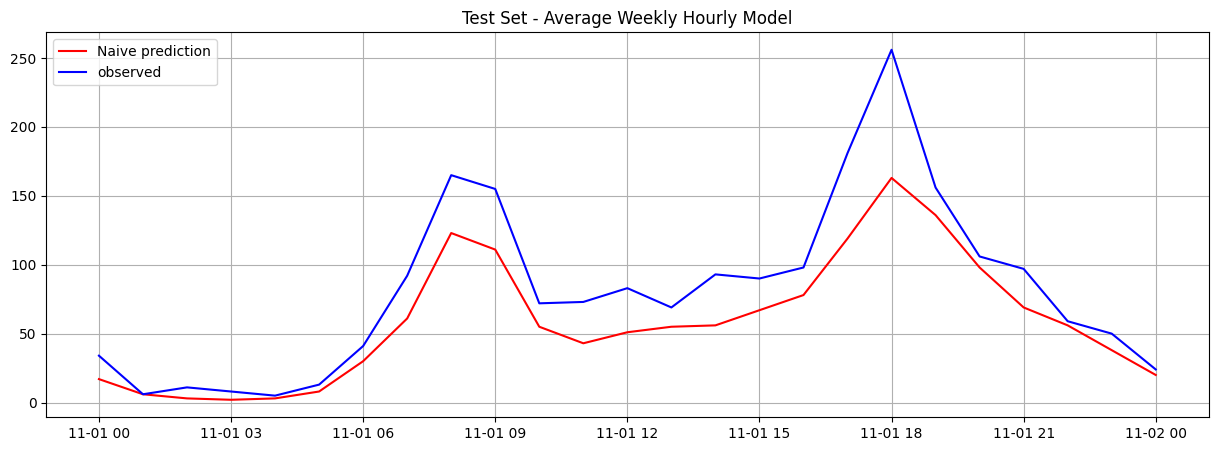

In [57]:
plotprediction(
    test_arrivals[:25],
    pred_test_arrivals[:25],
    labels=["observed", "Naive prediction"],
    title="Test Set - Average Weekly Hourly Model"
)

In [58]:
grouped_arrivals

,trip_count,is_weekend,most_common_user_type,most_common_gender,duration_mean,birth_mean
datetime,,,,,,
2018-01-01 00:00:00,4,False,Subscriber,1,414.250000,1982.750000
2018-01-01 01:00:00,5,False,Subscriber,1,1337.000000,1981.200000
2018-01-01 02:00:00,6,False,Subscriber,1,713.666667,1976.666667
2018-01-01 03:00:00,5,False,Subscriber,1,1105.000000,1986.400000
2018-01-01 04:00:00,5,False,Subscriber,1,374.200000,1977.200000
...,...,...,...,...,...,...
2019-01-04 19:00:00,0,0,0,0,0.000000,0.000000
2019-01-04 20:00:00,0,0,0,0,0.000000,0.000000
2019-01-04 21:00:00,0,0,0,0,0.000000,0.000000


### Eval. of Naive model

In [59]:
print_stats(test_arrivals, pred_test_arrivals, "Naive method arrivals")

Naive method arrivals: 
	r^2=0.407505
	MSE=920.019809
	MAE=18.970628
	MAPE=inf


# Naive model  - Prediction bike allocation

In [60]:

naive_bike_alloc_pred = (pred_test_arrivals - pred_test_departures).to_frame(name="diff")
naive_bike_alloc_pred["daily_cumsum"] = naive_bike_alloc_pred.groupby(naive_bike_alloc_pred.index.date)["diff"].cumsum()

In [61]:
min_daily_cumsum_pred = naive_bike_alloc_pred.groupby(naive_bike_alloc_pred.index.date).agg(
    min_daily_cumsum=("daily_cumsum", "min")
)

min_daily_cumsum_pred["bikes_to_allocate"] = (
    min_daily_cumsum_pred["min_daily_cumsum"]
    .apply(lambda x: abs(x) if x < 0 else 0)
)
min_daily_cumsum_pred


,min_daily_cumsum,bikes_to_allocate
2018-11-01,-159.0,159.0
2018-11-02,-151.0,151.0
2018-11-03,-93.0,93.0
2018-11-04,-72.0,72.0
2018-11-05,-137.0,137.0
...,...,...
2018-12-27,-159.0,159.0
2018-12-28,-151.0,151.0
2018-12-29,-93.0,93.0
2018-12-30,-72.0,72.0


In [62]:

naive_bike_alloc_test = (test_arrivals - test_departures).to_frame(name="diff")
naive_bike_alloc_test["daily_cumsum"] = naive_bike_alloc_test.groupby(naive_bike_alloc_test.index.date)["diff"].cumsum()

In [63]:
min_daily_cumsum_test = naive_bike_alloc_test.groupby(naive_bike_alloc_test.index.date).agg(
    min_daily_cumsum=("daily_cumsum", "min")
)

min_daily_cumsum_test["bikes_to_allocate"] = (
    min_daily_cumsum_test["min_daily_cumsum"]
    .apply(lambda x: abs(x) if x < 0 else 0)
)

min_daily_cumsum_test.to_json("min_daily_cumsum_test_4.json")

min_daily_cumsum_test

,min_daily_cumsum,bikes_to_allocate
2018-11-01,-187,187
2018-11-02,-122,122
2018-11-03,-85,85
2018-11-04,-146,146
2018-11-05,-94,94
...,...,...
2018-12-27,-80,80
2018-12-28,-26,26
2018-12-29,-81,81
2018-12-30,-50,50


In [64]:
print_stats(min_daily_cumsum_test["bikes_to_allocate"], min_daily_cumsum_pred["bikes_to_allocate"], title="Evaluation of allocation naive")

Evaluation of allocation naive: 
	r^2=-0.289133
	MSE=3198.721311
	MAE=42.262295
	MAPE=133.093406
